# Seminar 2 — Linear Regression with Two Features
## Independent work: derive it yourself, from formulas to code

**Goal:** build, train and interpret a linear regression model $y \approx w_1 x_1 + w_2 x_2 + b$ *from scratch* (NumPy only), and compare it with `sklearn`.

**You will learn to:**
- write down the model and the MSE loss;
- set up the system of linear equations for the exact solution and solve it;
- implement solution in NumPy;
- scale features, split train/test
- visualise the regression plane in 3D and interpret $w_1, w_2, b$.

**Notation used in this notebook:**
- one object: $(x_{i1}, x_{i2}, y_i)$ — two numbers (features) and the answer;
- unknowns: $b$ (intercept), $w_1, w_2$ (slopes);
- prediction for object $i$: $\hat y_i = b + w_1 x_{i1} + w_2 x_{i2}$

> How to work with this notebook: read theory blocks, fill in every cell marked ✏️ **TODO / YOUR CODE HERE**, run cells top-to-bottom. Cells with tests will tell you if you are correct.

## 1. Theory reminder (read carefully — no matrix calculus, only school algebra)

### 1.1 Model
For each object $i$:
$$
\hat y_i = b + w_1 x_{i1} + w_2 x_{i2}
$$
Three unknown numbers: $b, w_1, w_2$.

### 1.2 Loss: Mean Squared Error
Average squared miss over all $n$ objects:
$$
J(b, w_1, w_2) = \frac{1}{n}\sum_{i=1}^{n}(\hat y_i - y_i)^2
= \frac{1}{n}\sum_{i=1}^{n}(b + w_1 x_{i1} + w_2 x_{i2} - y_i)^2
$$
Small $J$ = plane is close to the points.

### 1.3 Solution — exact answer via a system of 3 linear equations
The best plane is at the bottom of the bowl $J$: all three ordinary derivatives are zero.
Using the chain rule $(u^2)' = 2u \cdot u'$ for each unknown:
$$
\frac{\partial J}{\partial b} = \frac{2}{n}\sum_{i=1}^{n}(\hat y_i - y_i), \quad
\frac{\partial J}{\partial w_1} = \frac{2}{n}\sum_{i=1}^{n}(\hat y_i - y_i)\, x_{i1}, \quad
\frac{\partial J}{\partial w_2} = \frac{2}{n}\sum_{i=1}^{n}(\hat y_i - y_i)\, x_{i2}
$$
Set each derivative to $0$ and open the brackets $\hat y_i = b + w_1 x_{i1} + w_2 x_{i2}$.
We get a familiar object — a system of 3 linear equations in 3 unknowns $b, w_1, w_2$:
$$
\begin{cases}
n \cdot b + w_1\sum x_{i1} + w_2\sum x_{i2} = \sum y_i \\
b\sum x_{i1} + w_1\sum x_{i1}^2 + w_2\sum x_{i1}x_{i2} = \sum x_{i1} y_i \\
b\sum x_{i2} + w_1\sum x_{i1}x_{i2} + w_2\sum x_{i2}^2 = \sum x_{i2} y_i
\end{cases}
$$
All sums are over $i = 1 \dots n$ and are just numbers you compute from the data.
So: compute 6 sums, fill a $3 \times 3$ table, solve the system (e.g. with `np.linalg.solve`) — done, no iterations.
If the equations are almost copies of each other (features $x_1 \approx x_2$), the system has no stable solution — more on that in Task 7.

✏️ **Paper exercise (do before coding):** on paper, take $J = \frac{1}{n}\sum(b + w_1 x_{i1} + w_2 x_{i2} - y_i)^2$ and differentiate it once by $b$, once by $w_1$, once by $w_2$ using only $(u^2)' = 2u\cdot u'$. Check you get the three formulas above.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3D projection)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
print("numpy:", np.__version__)

numpy: 1.21.2


## 2. Data: synthetic problem with known ground truth

We generate $n=300$ points:
$$
x_1 \sim U(0, 10), \quad x_2 \sim U(0, 10), \quad y = b_{true} + w^{true}_1 x_1 + w^{true}_2 x_2 + \varepsilon, \; \varepsilon \sim \mathcal{N}(0, \sigma^2)
$$
with $w^{true} = (2.5, -1.8)$, $b_{true} = 4.0$, $\sigma = 2.0$.

We know the answer in advance — perfect for checking your implementation: your estimated $w, b$ should be close to the true ones.

In [16]:
# ---- Synthetic dataset (given, no need to modify) ----
n_samples = 300
w_true = np.array([2.5, -1.8])
b_true = 4.0
sigma = 2.0

rng = np.random.default_rng(42)
X = rng.uniform(0, 10, size=(n_samples, 2))
noise = rng.normal(0, sigma, size=n_samples)
y = b_true + w_true[0] * X[:, 0] + w_true[1] * X[:, 1] + noise

df = pd.DataFrame(X, columns=["x1", "x2"])
df["y"] = y
print(df.head())
print("\nTrue params: w =", w_true, ", b =", b_true)

         x1        x2          y
0  7.739560  4.388784  17.944989
1  8.585979  6.973680  12.407289
2  0.941773  9.756224 -10.479860
3  7.611397  7.860643   4.059491
4  1.281136  4.503859  -3.216801

True params: w = [ 2.5 -1.8] , b = 4.0


## 3. ✏️ Task 1 — Exploratory data analysis (EDA)

Answer with plots and numbers:
1. What are the means / stds / mins / maxes of `x1`, `x2`, `y`?
2. How does `y` depend on `x1` and on `x2` (scatter plots)? Do the slopes look positive or negative?
3. What is the correlation between `x1` and `x2`? Why does it matter for linear regression?

Fill in the TODOs in the next cell.

               x1          x2           y
count  300.000000  300.000000  300.000000
mean     4.786540    5.133191    6.598114
std      2.948209    2.788406    8.821719
min      0.054298    0.073623  -11.609961
25%      1.977618    2.718149   -0.291815
50%      4.694414    5.146400    6.642182
75%      7.489248    7.527057   13.147299
max      9.970347    9.991047   26.835740

Correlation matrix:
          x1        x2         y
x1  1.000000  0.045942  0.791375
x2  0.045942  1.000000 -0.528003
y   0.791375 -0.528003  1.000000


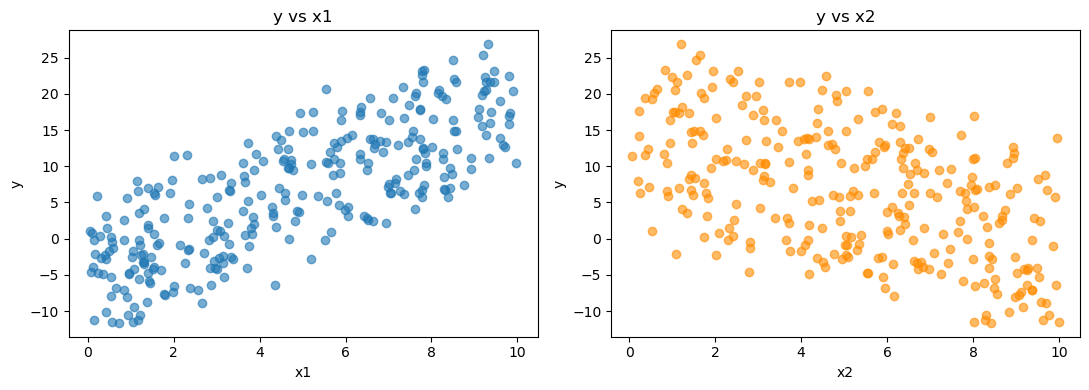

In [3]:
# ✏️ TODO 1: basic statistics
print(df.describe())
print("\nCorrelation matrix:")
# TODO: compute correlation matrix of df (hint: df.corr())
corr = # <-- YOUR CODE HERE (replace if needed)
print(corr)

# Scatter plots: y vs x1 and y vs x2
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(df["x1"], df["y"], alpha=0.6)
axes[0].set_xlabel("x1"); axes[0].set_ylabel("y"); axes[0].set_title("y vs x1")
axes[1].scatter(df["x2"], df["y"], alpha=0.6, color="darkorange")
axes[1].set_xlabel("x2"); axes[1].set_ylabel("y"); axes[1].set_title("y vs x2")
plt.tight_layout(); plt.show()

# ✏️ QUESTION (write answer as a comment below):
# Q1: sign of slope y~x1? y~x2?
# Q2: corr(x1, x2) ≈ ? Is there multicollinearity here?
# YOUR ANSWER HERE

## 4. Train / test split

We split 80% train / 20% test with a fixed `random_state` so results are reproducible. **Always fit scalers and weights on train only!**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("train:", X_train.shape, y_train.shape, " test:", X_test.shape, y_test.shape)

train: (240, 2) (240,)  test: (60, 2) (60,)


## 5. ✏️ Task 2 — Feature scaling (standardisation)

Solution converges much faster when features are on the same scale. Standardise using **train** statistics:
$$
x'_{j} = \frac{x_j - \mu_j}{\sigma_j}
$$
✏️ Implement `fit_standardize` (compute $\mu, \sigma$ on train) and `apply_standardize`. Handle $\sigma_j = 0$ to avoid division by zero.

In [5]:
# ✏️ TODO 2: implement standardisation
def fit_standardize(X):
    """Return (mu, sigma) computed on X. sigma==0 -> replaced with 1."""
    # YOUR CODE HERE

    return mu, sigma

def apply_standardize(X, mu, sigma):
    """Apply z-score normalisation."""
    # YOUR CODE HERE
    return 

mu_train, sigma_train = fit_standardize(X_train)
X_train_s = apply_standardize(X_train, mu_train, sigma_train)
X_test_s = apply_standardize(X_test, mu_train, sigma_train)  # NB: use TRAIN stats!

print("mu:", mu_train, " sigma:", sigma_train)
print("scaled train mean:", X_train_s.mean(axis=0).round(6), " std:", X_train_s.std(axis=0).round(6))
# Self-check: scaled train mean ≈ 0, std ≈ 1
assert np.allclose(X_train_s.mean(axis=0), 0, atol=1e-8), "mean should be ~0"
assert np.allclose(X_train_s.std(axis=0), 1, atol=1e-8), "std should be ~1"
print("Task 2 OK ✓")

mu: [4.74543936 5.22000722]  sigma: [2.94941965 2.79032598]
scaled train mean: [-0. -0.]  std: [1. 1.]
Task 2 OK ✓


## 6. ✏️ Task 3 — Exact solution: solve a system of 3 equations

From Section 1.3, the optimum satisfies:
$$
\begin{cases}
n \cdot b + w_1\sum x_{i1} + w_2\sum x_{i2} = \sum y_i \\
b\sum x_{i1} + w_1\sum x_{i1}^2 + w_2\sum x_{i1}x_{i2} = \sum x_{i1} y_i \\
b\sum x_{i2} + w_1\sum x_{i1}x_{i2} + w_2\sum x_{i2}^2 = \sum x_{i2} y_i
\end{cases}
$$
Steps:
1. compute the 6 sums ($\sum x_1, \sum x_2, \sum x_1^2, \sum x_2^2, \sum x_1 x_2, \sum x_1 y, \sum x_2 y, \sum y$) on the **scaled** train data;
2. pack them into a $3 \times 3$ table `A` and right-hand side `c` (unknown order: $[b, w_1, w_2]$);
3. solve with `np.linalg.solve(A, c)`.

Fit on the **scaled** train data. Here we just stay in scaled space and report scaled-space weights, plus compare with sklearn trained on the same scaled data.

In [6]:
def normal_equation(X, y):
    """Exact least squares via a system of 3 linear equations.
    Unknown order: [b, w1, w2]. Sums are plain numbers from the data."""
    # ✏️ TODO 3: fill the 3x3 table and right-hand side from the formulas in Sec. 1.3
    # YOUR CODE HERE
    return theta

theta_closed = normal_equation(X_train_s, y_train)
b_closed, w_closed = theta_closed[0], theta_closed[1:]
print(f"Closed form (scaled space): b={b_closed:.4f}, w={w_closed}")
print(f"True params (original space): b={b_true}, w={w_true} — not directly comparable before unscaling, see Task 6.")

Closed form (scaled space): b=6.3318, w=[ 7.15512429 -5.04111044]
True params (original space): b=4.0, w=[ 2.5 -1.8] — not directly comparable before unscaling, see Task 6.


## 10. Visualisation: the regression plane

With two features the model is a **plane** in 3D $(x_1, x_2, y)$. Below we plot train points + the fitted plane (using the closed-form solution), plus residuals on test.

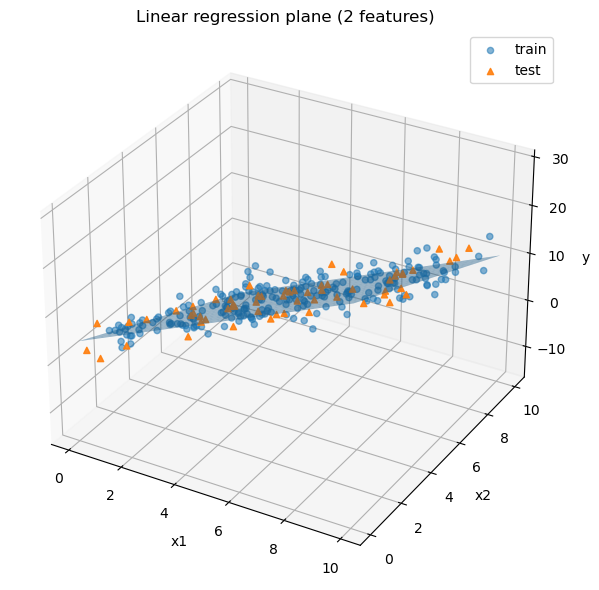

In [11]:
# 3D plane (given — just run)
xx1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 30)
xx2 = np.linspace(X[:, 1].min(), X[:, 1].max(), 30)
G1, G2 = np.meshgrid(xx1, xx2)
# plane in ORIGINAL space using unscaled params
Gp = b_closed + w_closed[0] * G1 + w_closed[1] * G2

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_train[:, 0], X_train[:, 1], y_train, alpha=0.55, label="train")
ax.scatter(X_test[:, 0], X_test[:, 1], y_test, alpha=0.9, marker="^", label="test")
ax.plot_surface(G1, G2, Gp, alpha=0.45, edgecolor="none")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("y")
ax.set_title("Linear regression plane (2 features)")
ax.legend(); plt.tight_layout(); plt.show()